In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Configuración de visualización
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Cargar el dataset
df = pd.read_csv('../../Dataset/default of credit card clients.csv', header=1, delimiter=',')

# Visualizar las primeras filas
display(df.head())
print(f"Dimensiones del dataset: {df.shape}")

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


Dimensiones del dataset: (30000, 25)


In [3]:

# La columna 'default.payment.next.month' es la que indica si hubo impago (1) o no (0).
# El ID no aporta valor estadístico.
features_to_drop = ['ID', 'default.payment.next.month']
X = df.drop(columns=features_to_drop, errors='ignore')

# 2. Estandarización (Z-score normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
k_range = range(2, 11) # Evaluamos desde 2 hasta 10 clusters
inertias = []
silhouette_scores = []

for k in k_range:
    # n_init=10 asegura que el algoritmo corra 10 veces con distintas semillas para evitar mínimos locales
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

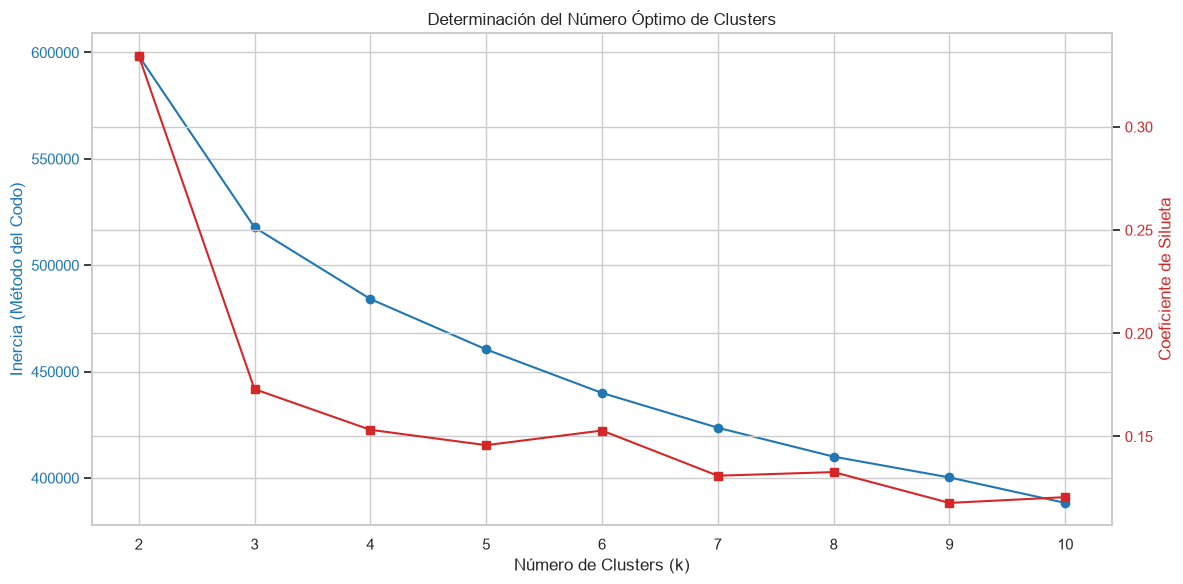

In [5]:
# Gráfico combinado
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (Método del Codo)', color=color)
ax1.plot(k_range, inertias, marker='o', color=color, label='Inercia')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Coeficiente de Silueta', color=color)  
ax2.plot(k_range, silhouette_scores, marker='s', color=color, label='Silueta')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Determinación del Número Óptimo de Clusters')
fig.tight_layout()
plt.show()

In [6]:
# Definimos el número óptimo de clusters (ej. 3)
optimal_k = 3 

# Entrenar el modelo final
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Guardar el dataset original con las etiquetas para el análisis de negocio
df_clustered = df.copy()
df_clustered['Cluster'] = kmeans_final.labels_

print(f"Modelo K-Means entrenado con éxito para k={optimal_k}.")

Modelo K-Means entrenado con éxito para k=3.


In [12]:
# Variables clave para el negocio
key_vars = ['LIMIT_BAL', 'AGE', 'PAY_0', 'BILL_AMT1', 'PAY_AMT1', 'default payment next month']

# Agrupar y calcular medias
cluster_profile = df_clustered.groupby('Cluster')[key_vars].mean()

# Calcular tasa de default por cluster
default_rate = df_clustered.groupby('Cluster')['default payment next month'].mean() * 100
cluster_profile['Tasa_Default_%'] = default_rate

# Formatear para mejor lectura
display(cluster_profile.round(2))


,LIMIT_BAL,AGE,PAY_0,BILL_AMT1,PAY_AMT1,default payment next month,Tasa_Default_%
Cluster,,,,,,,
0,105573.43,34.52,0.42,44690.84,3727.54,0.27,27.14
1,220788.18,36.41,-0.77,10306.16,4890.98,0.16,15.88
2,283365.97,37.02,0.25,199693.48,16428.60,0.18,18.33


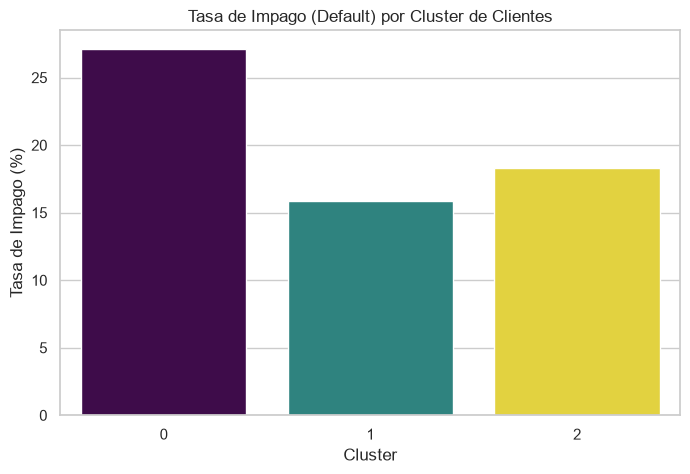

In [14]:
# Gráfico de barras de Tasa de Default por Cluster
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=cluster_profile.reset_index(),
    x='Cluster',
    y='Tasa_Default_%',
    hue='Cluster',
    palette='viridis',
    legend=False
)
plt.title('Tasa de Impago (Default) por Cluster de Clientes')
plt.xlabel('Cluster')
plt.ylabel('Tasa de Impago (%)')
plt.show()

In [16]:
# Como tenemos más de 20 dimensiones, no podemos graficar directamente.
# Usamos PCA (Análisis de Componentes Principales) para reducir a 2D.

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Crear DataFrame para graficar
pca_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = df_clustered['Cluster'].astype(str)
pca_df['Default'] = df_clustered['default payment next month']


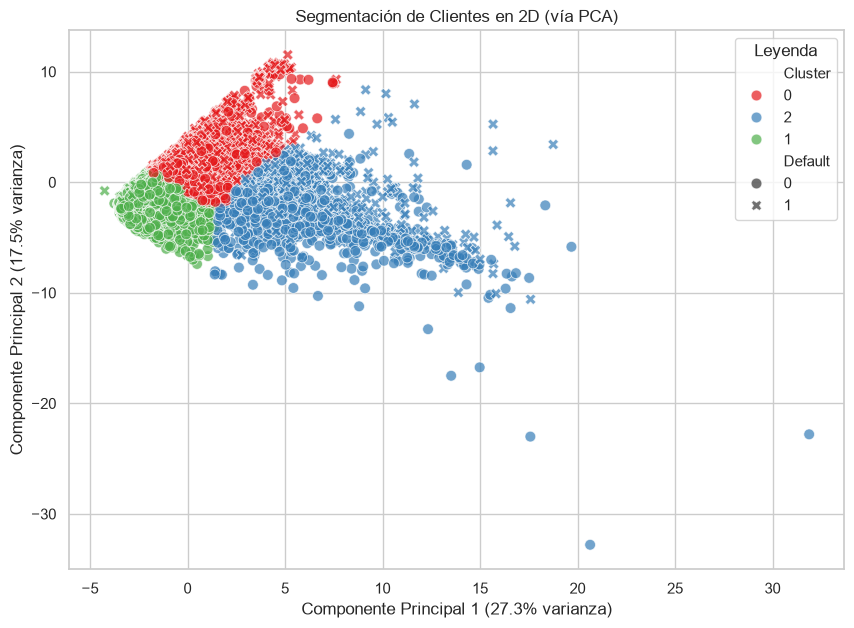

In [17]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', style='Default', 
                palette='Set1', alpha=0.7, s=60, data=pca_df)
plt.title('Segmentación de Clientes en 2D (vía PCA)')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.legend(title='Leyenda')
plt.show()